# Stage 7 — Statewide Application (frozen method)

Applies the exact same method developed and frozen at Mole Creek
(Stages 2, 3, 5, 6) across the whole of Tasmania, at a coarser
resolution. Per the plan: "the workflow was developed
and tested at the Mole Creek case-study scale," then applied statewide
as-is, so Stage 8 can meaningfully compare the two.

**What's deliberately skipped here, and why:** the Stage 2 geology
cross-check and the Stage 3 DEM flow-accumulation comparison were
*validation exercises* at Mole Creek — they don't
need repeating statewide as part of "applying the method." Only the
actual frozen formula runs here: karst intensity × exposure →
connectivity → × land-use pressure → risk.

**Resolution:** coarsened to **100 m** (from the native 25 m DEM built in
Stage 1). Tested first: the full statewide pipeline (DEM
resampling, Karst Atlas, DEA fetch, combination, zonal stats) runs in
about 20 seconds at this resolution — no need to go coarser.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import rasterize
from rasterio.mask import mask
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"
TARGET_CRS = "EPSG:7855"
COARSE_RES = 100

## 7.1 Coarse statewide DEM template (100 m)

Resampled from the Stage 1 25 m mosaic (average resampling — appropriate for downsampling continuous elevation, unlike the nearest-neighbour used for categorical layers).

In [2]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")

with rasterio.open(outpath / "dem_tas_EPSG7855.tif") as src:
    dst_transform, width, height = calculate_default_transform(
        src.crs, src.crs, src.width, src.height, *src.bounds, resolution=COARSE_RES
    )
    dem_coarse = np.full((height, width), src.nodata, dtype=src.dtypes[0])
    reproject(
        source=rasterio.band(src, 1), destination=dem_coarse,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=dst_transform, dst_crs=src.crs,
        src_nodata=src.nodata, dst_nodata=src.nodata,
        resampling=Resampling.average,
    )
    dem_nodata = src.nodata

template_profile = {
    "driver": "GTiff", "height": height, "width": width, "count": 1,
    "dtype": "float32", "crs": TARGET_CRS, "transform": dst_transform, "nodata": dem_nodata,
}
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif", "w", **template_profile) as dst:
    dst.write(dem_coarse.astype("float32"), 1)

# Mask to the actual Tasmania land polygon, not just the raster's rectangular
# extent (which includes surrounding ocean) -- matters for area-based statistics
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    land_masked, _ = mask(src, tasmania.geometry, crop=False, nodata=dem_nodata)
valid = land_masked[0] != dem_nodata
print(f"Coarse DEM template: {dem_coarse.shape}, {valid.sum()} valid land cells")

Coarse DEM template: (5020, 3987), 6797145 valid land cells


## 7.2 Karst susceptibility + connectivity — frozen from Stages 2 and 3, statewide

Identical reclassification logic, run over the full statewide Karst Atlas (2601 features) instead of the Mole Creek clip.

In [3]:
karst = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs(TARGET_CRS)
karst = karst[karst.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

CATEGORY_SCORE = {"A": 4, "B": 3, "C": 2, "D": 1, "0": 0}
karst["karst_intensity"] = karst["KCATEGORY"].map(CATEGORY_SCORE)

def exposure_type(row):
    if row["KEXPOSED"] != "0":
        return "exposed"
    if row["KCOVERED"] != "0":
        return "covered"
    if row["KINTERSTR"] != "0":
        return "interstratal"
    return "non-karst"
karst["exposure_type"] = karst.apply(exposure_type, axis=1)

AUTOGENIC_SCORE = {"exposed": 3, "covered": 3, "interstratal": 2, "non-karst": 0}
karst["autogenic_score"] = karst["exposure_type"].map(AUTOGENIC_SCORE)
karst["proximal_score"] = np.where(karst["KPROXCATCH"] != "0", 3, 0)
karst["distal_score"] = np.where(karst["KDISTCATCH"].astype(str) != "0", 1, 0)
karst["connectivity"] = karst[["autogenic_score", "proximal_score", "distal_score"]].max(axis=1)

print("Statewide karst intensity distribution (note: category C actually occurs here, unlike Mole Creek):")
print(karst["karst_intensity"].value_counts().sort_index())
print("\nStatewide connectivity distribution (note: genuine variation here, unlike Mole Creek's near-saturation):")
print(karst["connectivity"].value_counts().sort_index())

intensity_raster = rasterize(
    [(g, v) for g, v in zip(karst.geometry, karst["karst_intensity"])],
    out_shape=(height, width), transform=dst_transform, fill=0, dtype="uint8",
)
connectivity_raster = rasterize(
    [(g, v) for g, v in zip(karst.geometry, karst["connectivity"])],
    out_shape=(height, width), transform=dst_transform, fill=0, dtype="uint8",
)

Statewide karst intensity distribution (note: category C actually occurs here, unlike Mole Creek):
karst_intensity
0    924
1    260
2    329
3    758
4    330
Name: count, dtype: int64

Statewide connectivity distribution (note: genuine variation here, unlike Mole Creek's near-saturation):
connectivity
0     455
1       1
2       3
3    2142
Name: count, dtype: int64


## 7.3 Land-use pressure — frozen from Stage 5, statewide

Now via the shared `fetch_landuse_pressure()` in `src/landuse.py` (also used by Stage 5) -- same STAC access pattern, same `PRESSURE_RECLASS` lookup, no longer duplicated here. Checked before
building this: every Level-3 class that actually occurs statewide (111,
112, 124, 215, 216, 220, 255) is already covered by the Stage 5 table —
no gaps to patch.

In [4]:
tas_wgs84 = tasmania.to_crs("EPSG:4326")
bbox = tas_wgs84.total_bounds.tolist()

pressure_aligned = fetch_landuse_pressure(bbox, 2020, outpath / "dem_tas_100m_EPSG7855.tif", target_crs=TARGET_CRS)

print("Pressure aligned to statewide template:", pressure_aligned.shape)

Pressure aligned to statewide template: (5020, 3987)


## 7.4 Combine — frozen formula from Stages 4 and 6

In [5]:
intensity_norm = intensity_raster.astype(float) / 4.0
connectivity_norm = connectivity_raster.astype(float) / 3.0
intrinsic = intensity_norm * connectivity_norm

pressure_valid = pressure_aligned != 255
pressure_norm = np.where(pressure_valid, pressure_aligned.astype(float) / 3.0, np.nan)

risk = intrinsic * pressure_norm
risk_valid = valid & pressure_valid
risk = np.where(risk_valid, risk, np.nan)

present = sorted(np.unique(risk[risk_valid]))
print(f"Distinct statewide risk values ({len(present)}):", present)

vals, counts = np.unique(risk[risk_valid], return_counts=True)
print("\nClass distribution (% of valid Tasmania land area):")
for v, c in zip(vals, counts):
    print(f"  {v:.4f}: {c} cells ({c/risk_valid.sum()*100:.2f}%)")

Distinct statewide risk values (9): [np.float64(0.0), np.float64(0.08333333333333333), np.float64(0.1111111111111111), np.float64(0.16666666666666666), np.float64(0.25), np.float64(0.3333333333333333), np.float64(0.5), np.float64(0.75), np.float64(1.0)]

Class distribution (% of valid Tasmania land area):
  0.0000: 6392351 cells (94.06%)
  0.0833: 79847 cells (1.17%)
  0.1111: 7 cells (0.00%)
  0.1667: 21528 cells (0.32%)
  0.2500: 122028 cells (1.80%)
  0.3333: 118227 cells (1.74%)
  0.5000: 3717 cells (0.05%)
  0.7500: 49892 cells (0.73%)
  1.0000: 8370 cells (0.12%)


## 7.5 Classify and save

9 distinct values occur statewide (vs. 6 at Mole Creek) — more combinations exist now that karst category C and genuinely variable connectivity are both in play.

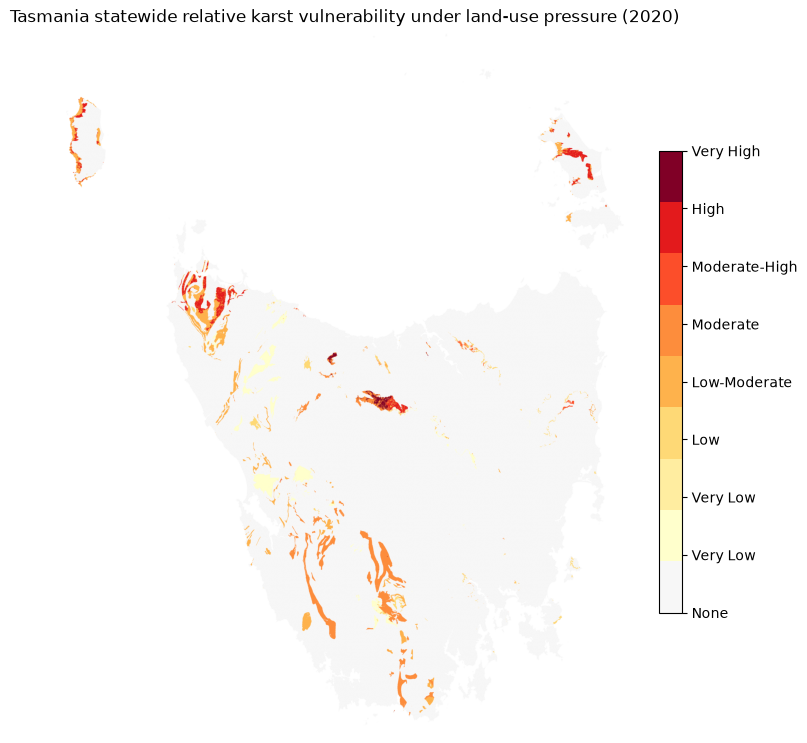

In [6]:
LABELS = ["None", "Very Low", "Very Low", "Low", "Low-Moderate", "Moderate", "Moderate-High", "High", "Very High"]
assert len(LABELS) == len(present), f"Expected {len(present)} labels, got {len(LABELS)} -- update LABELS if this changes"

risk_class = np.full(risk.shape, 255, dtype="uint8")
for i, val in enumerate(present):
    risk_class[risk_valid & np.isclose(risk, val)] = i

out_profile = template_profile.copy()
out_profile.update(dtype="uint8", nodata=255)
with rasterio.open(outpath / "risk_class_tas_2020_100m_EPSG7855.tif", "w", **out_profile) as dst:
    dst.write(risk_class, 1)

risk_profile = template_profile.copy()
risk_out = np.where(risk_valid, risk, template_profile["nodata"]).astype("float32")
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif", "w", **risk_profile) as dst:
    dst.write(risk_out, 1)

cmap = ListedColormap(["#f7f7f7", "#ffffcc", "#ffeda0", "#fed976", "#feb24c", "#fd8d3c", "#fc4e2a", "#e31a1c", "#800026"])
display = np.ma.masked_equal(risk_class, 255)
plt.figure(figsize=(9, 12))
plt.imshow(display, cmap=cmap, vmin=0, vmax=len(present) - 1)
cbar = plt.colorbar(ticks=range(len(present)), shrink=0.5)
cbar.ax.set_yticklabels(LABELS)
plt.title("Tasmania statewide relative karst vulnerability under land-use pressure (2020)")
plt.axis("off")
plt.show()

## 7.6 Plausibility check: named karst areas, statewide

Same check as Stage 6, now over all 1677 statewide karst polygons
(zonal stats over all of them takes under a second — no scaling
concern).

In [7]:
karst_only = karst[karst["karst_intensity"] > 0].copy()
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    means = []
    for _, row in karst_only.iterrows():
        out_image, _ = mask(src, [row.geometry], crop=True, nodata=risk_profile["nodata"])
        vals_ = out_image[0]
        vals_ = vals_[vals_ != risk_profile["nodata"]]
        means.append(vals_.mean() if len(vals_) else np.nan)
karst_only["mean_risk"] = means

top = karst_only.groupby("KNAME")["mean_risk"].mean().sort_values(ascending=False)
print("Top 15 statewide karst areas by mean risk:")
print(top.head(15))

Top 15 statewide karst areas by mean risk:
KNAME
Vinegar Hill                      0.750000
Geilston Bay                      0.750000
Welcome River (1) / Port Hills    0.750000
Mole Creek  (Chudleigh Hill)      0.743590
Fairview (Redpa) (2)              0.740455
Brittons Swamp                    0.721966
Sawards  Creek                    0.720833
Flowery Gully                     0.713889
Lackrana                          0.693731
Emita - Memana (2)                0.684617
Irishtown - Sedgy Creek (3)       0.645833
Irishtown - Sedgy Creek (2)       0.622642
Port Hills                        0.618421
Fairview (Redpa) (1 & 2)          0.614826
Mole Creek                        0.600377
Name: mean_risk, dtype: float64


## Cross-validation with the Mole Creek prototype

**Mole Creek (Chudleigh Hill)** ranks in the top 5 statewide, and
**Mole Creek** itself sits comfortably in the top 15 out of 1677 named
areas — consistent with Stage 6's own Mole-Creek-only finding that these
two were the highest-risk named areas there. That agreement is a
genuine cross-check, not a designed-to-pass one: Stage 6 only had 7
named areas to rank within Mole Creek; this run ranks all 1677 karst
areas in Tasmania independently, and the same two systems land near the
top of both.

Most of the other statewide top spots (Welcome River, Fairview/Redpa,
Irishtown-Sedgy Creek, Sawards Creek, Brittons Swamp) sit in the
**Smithton Basin / far northwest** — the same agricultural-karst
interaction region flagged in the very earliest brainstorming for this
project.

## Stage 7 outputs

- `dem_tas_100m_EPSG7855.tif` — coarse statewide DEM template
- `risk_tas_2020_100m_EPSG7855.tif` — continuous statewide risk
- `risk_class_tas_2020_100m_EPSG7855.tif` — classified statewide risk

**Next (Stage 8):** compare this statewide-coarse output against the
Mole-Creek-detailed result (Stage 6) for the Mole Creek area
specifically — does the frozen method, applied at 100 m statewide,
agree with what the same method produced at 25 m locally?